In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from various import read_atoms_from_output_dumps, get_distance, get_distribution

In [3]:
laamps_path = "/mnt/7E442D59442D1585/md/paper/melting/v2_to_send_results/laamps"

In [8]:
atom_data = read_atoms_from_output_dumps(laamps_path, 783, 57)

In [9]:
distance = get_distance(atom_data, 783, 57)

(1.8e-10, 2.6e-10)

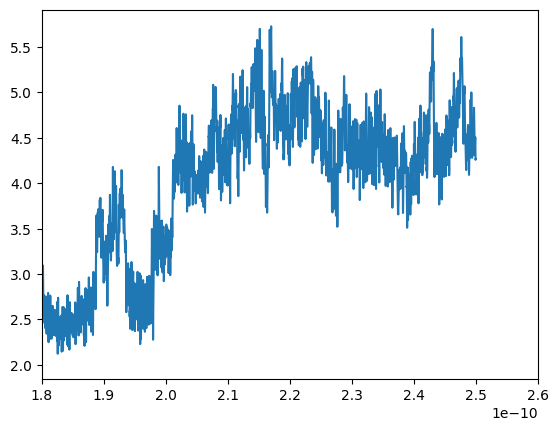

In [18]:
plt.figure()
plt.plot(distance['iteration'] * 1e-15, distance['distance'])
plt.xlim([1.8e-10, 2.6e-10])

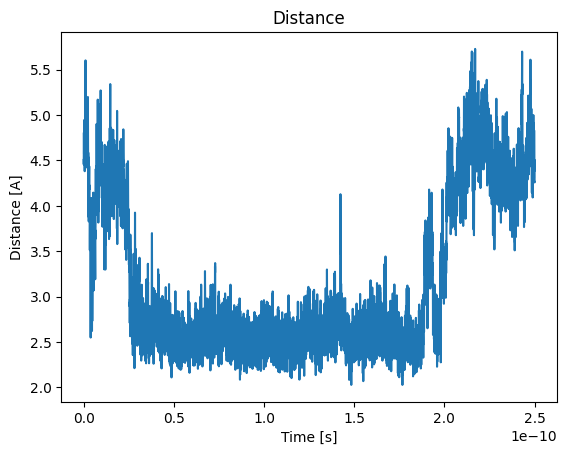

In [62]:
plt.figure()
plt.plot(distance['iteration'] * 1e-15, distance['distance'])
plt.title("Distance")
plt.xlabel("Time [s]")
plt.ylabel("Distance [A]")
plt.savefig("/mnt/7E442D59442D1585/md/paper/melting/v2_to_send_results/melting_plots/distance.png")

In [77]:
time_elapsed = distance['iteration'] * 1e-15
rolling_distance = distance['distance'].rolling(window=2000)

print(distance.shape)
print(rolling_distance.mean().shape)

(250001, 2)
(250001,)


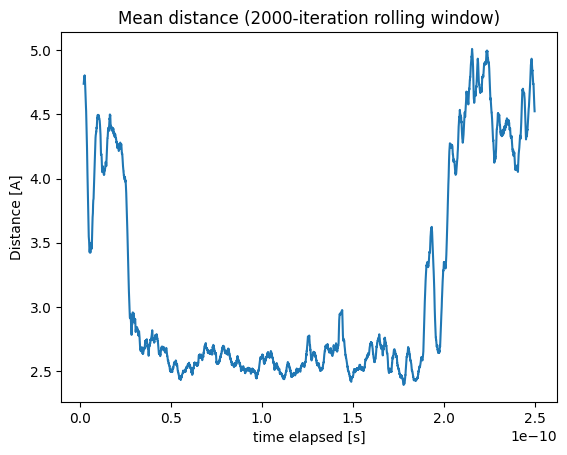

In [67]:
plt.figure()
plt.plot(time_elapsed, rolling_distance.mean())
plt.xlabel("time elapsed [s]")
plt.ylabel("Distance [A]")
plt.title("Mean distance (2000-iteration rolling window)")
plt.savefig("/mnt/7E442D59442D1585/md/paper/melting/v2_to_send_results/melting_plots/distance_2000_window_mean.png")
plt.show()

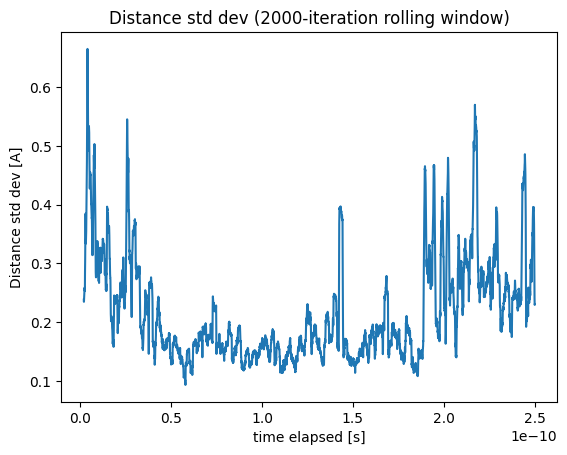

In [69]:
plt.figure()
plt.plot(time_elapsed, rolling_distance.std())
plt.xlabel("time elapsed [s]")
plt.ylabel("Distance std dev [A]")
plt.title("Distance std dev (2000-iteration rolling window)")
plt.savefig("/mnt/7E442D59442D1585/md/paper/melting/v2_to_send_results/melting_plots/distance_2000_window_std_dev.png")
plt.show()

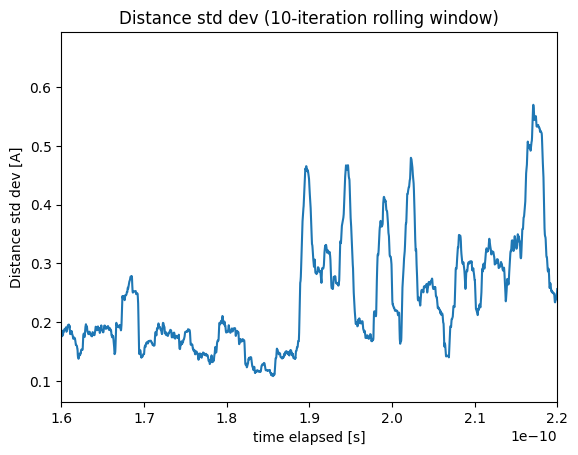

In [70]:
plt.figure()
plt.plot(time_elapsed, rolling_distance.std())
plt.xlabel("time elapsed [s]")
plt.ylabel("Distance std dev [A]")
plt.title("Distance std dev (10-iteration rolling window)")
plt.xlim([1.6e-10, 2.2e-10])
plt.savefig("/mnt/7E442D59442D1585/md/paper/melting/v2_to_send_results/melting_plots/distance_2000_window_std_dev_zoom.png")
plt.show()

In [47]:
import math

iteration = math.ceil(1.9e-10 / 1e-15)
print(iteration)

190000


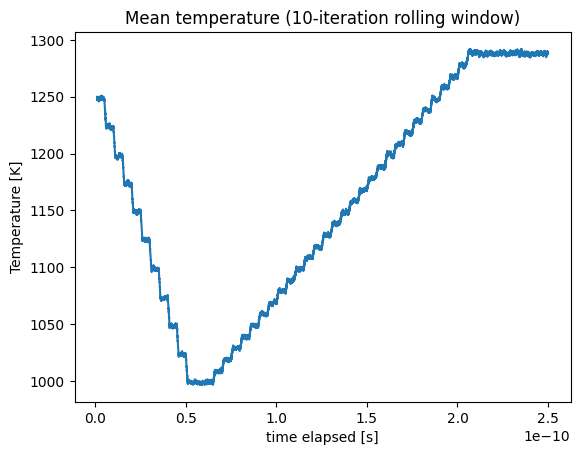

In [75]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

k_b = 8.617333e-5  # eV/K

path = "/mnt/7E442D59442D1585/md/paper/melting/v2_to_send_results"  # adjust to your output dir

with open(Path(path) / "particles_initial.json", encoding="utf-8") as f:
  particles_initial = json.load(f)
num_atoms = sum(
  1 for particle in particles_initial["particles"] if particle["particle_type"] == "Atom"
)

energy_data = pd.read_csv(path + "/energy.csv", header=0)
mean_kinetic_energy = energy_data["kinetic_energy_atom"] / num_atoms
temperature = 2 / 3 * mean_kinetic_energy / k_b
time_elapsed = energy_data["iteration"] * 1e-15

rolling_temperature = temperature.rolling(window=50)

plt.figure()
plt.plot(time_elapsed, rolling_temperature.mean())
plt.xlabel("time elapsed [s]")
plt.ylabel("Temperature [K]")
plt.title("Mean temperature (10-iteration rolling window)")
plt.savefig("/mnt/7E442D59442D1585/md/paper/melting/v2_to_send_results/melting_plots/temperature_2000_window_mean.png")
plt.show()

In [54]:
print(energy_data.columns)
print(energy_data.shape)

Index(['iteration', 'kinetic_energy_atom', 'kinetic_energy_other',
       'potential_energy', 'potential_gravity_energy', 'total_energy',
       'p_control_energy_total', 'thermostat_work_total',
       'thermostat_epsilon'],
      dtype='str')
(12501, 9)


In [56]:
print(distance.shape)
print(distance.columns)
print(250000 / 12500)

(250001, 2)
Index(['iteration', 'distance'], dtype='str')
20.0


In [73]:
print(rolling_temperature)
print(rolling_temperature.mean().shape)
print(rolling_temperature.mean()[200000 / 20])

Rolling [window=50,center=False,method=single]
(12501,)
1267.2186412122383
